# GK-05 Round 4 — Black Box Reconstruction

## 1. Problem Statement

GK-05 represents a building access control system.

The system receives a badge request containing several features and returns:

- A confidence score between 0 and 1
- A decision: APPROVE or DECLINE

The objective of this project is to build a small machine learning model that approximates the behavior of the GK-05 black-box system.

## 2. GK-05 Features

The model uses the following input features:

| Feature | Range |
|---|---|
| clearance_level | 0–100 |
| badge_age_days | 18–75 |
| tenure_years | 0–40 |
| anomaly_ratio | 0–1 |
| history_score | 300–900 |
| linked_badges | 0–20 |
| recent_denials | 0–5 |
| requested_zone | 0–100 |
| escorts | 0–6 |
| site | A, B, C, D |

### Output

- Confidence score: 0–1
- Decision: APPROVE or DECLINE

In [ ]:
import pandas as pd

data = [
    [100,24,34,0,350,19,0,37,6,"A",0.9922],
    [100,24,34,0,300,19,0,37,6,"A",0.9895],
    [100,24,34,0,350,19,0,40,6,"A",0.9903],
    [100,24,30,0,350,19,0,37,6,"A",0.9884],
    [100,20,34,0,350,19,0,37,6,"A",0.9888],
    [100,24,34,0,350,15,0,37,6,"A",0.9904],
    [100,24,34,0,350,10,0,37,6,"A",0.9731],
    [100,24,34,0.5,350,19,0,37,6,"A",0.9922],
    [100,24,34,0,350,19,2,37,6,"A",0.9876],
    [50,24,34,0,350,19,0,37,6,"A",0.9922],
    [100,24,34,0,350,19,0,37,0,"A",0.9922],
    [100,24,34,0,350,19,0,37,6,"B",0.9919],
    [100,24,34,0,350,19,0,37,6,"C",0.9899],
    [100,24,34,0,350,19,0,37,6,"D",0.9864],
    [100,24,34,0,350,19,0,35,6,"A",0.9923],
    [100,24,34,0,350,19,0,34,6,"A",0.9923],
    [100,30,34,0,350,19,0,37,6,"A",0.9884],
    [100,24,40,0,350,19,0,37,6,"A",0.9816],
    [100,24,34,0,350,10,2,37,6,"A",0.9631],
    [100,24,34,0,300,10,0,37,6,"A",0.9670],
    [100,24,34,0,350,10,0,37,6,"B",0.9751],
    [100,30,34,0,350,19,0,37,6,"B",0.9905],
    [100,24,34,0,350,19,0,40,6,"B",0.9897],
    [100,30,34,0,300,19,0,37,6,"A",0.9880],
    [100,24,34,0,300,19,0,40,6,"A",0.9860],
    [100,24,34,0,400,19,0,40,6,"A",0.9861],
    [100,20,34,0,300,19,0,37,6,"A",0.9887],
    [100,24,34,0,300,19,2,37,6,"A",0.9849],
    [100,30,34,0,350,10,0,37,6,"A",0.9718]
]

columns = [
    "clearance_level","badge_age_days","tenure_years",
    "anomaly_ratio","history_score","linked_badges",
    "recent_denials","requested_zone","escorts","site",
    "confidence"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,clearance_level,badge_age_days,tenure_years,anomaly_ratio,history_score,linked_badges,recent_denials,requested_zone,escorts,site,confidence
0,100,24,34,0.0,350,19,0,37,6,A,0.9922
1,100,24,34,0.0,300,19,0,37,6,A,0.9895
2,100,24,34,0.0,350,19,0,40,6,A,0.9903
3,100,24,30,0.0,350,19,0,37,6,A,0.9884
4,100,20,34,0.0,350,19,0,37,6,A,0.9888


In [ ]:
# Create the decision column
df["decision"] = df["confidence"].apply(
    lambda x: "APPROVE" if x >= 0.5 else "DECLINE"
)

# Display the dataset
df.head(10)

,clearance_level,badge_age_days,tenure_years,anomaly_ratio,history_score,linked_badges,recent_denials,requested_zone,escorts,site,confidence,decision
0,100,24,34,0.0,350,19,0,37,6,A,0.9922,APPROVE
1,100,24,34,0.0,300,19,0,37,6,A,0.9895,APPROVE
2,100,24,34,0.0,350,19,0,40,6,A,0.9903,APPROVE
3,100,24,30,0.0,350,19,0,37,6,A,0.9884,APPROVE
4,100,20,34,0.0,350,19,0,37,6,A,0.9888,APPROVE
5,100,24,34,0.0,350,15,0,37,6,A,0.9904,APPROVE
6,100,24,34,0.0,350,10,0,37,6,A,0.9731,APPROVE
7,100,24,34,0.5,350,19,0,37,6,A,0.9922,APPROVE
8,100,24,34,0.0,350,19,2,37,6,A,0.9876,APPROVE
9,50,24,34,0.0,350,19,0,37,6,A,0.9922,APPROVE


In [ ]:
from sklearn.model_selection import train_test_split

# Input features
X = df.drop(columns=["confidence", "decision"])

# Convert site A/B/C/D into numerical columns
X = pd.get_dummies(X, columns=["site"], dtype=int)

# Target: confidence score
y = df["confidence"]

print("Features:")
print(X.columns.tolist())

print("\nDataset shape:")
print(X.shape)

Features:
['clearance_level', 'badge_age_days', 'tenure_years', 'anomaly_ratio', 'history_score', 'linked_badges', 'recent_denials', 'requested_zone', 'escorts', 'site_A', 'site_B', 'site_C', 'site_D']

Dataset shape:
(29, 13)


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 23
Testing samples: 6


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create the Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model trained successfully!")
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Model trained successfully!
Mean Absolute Error: 0.0021049999999999867
R² Score: -0.4143250150822946


In [ ]:
import pandas as pd

# Load GK-05 dataset
df = pd.read_csv("DATASET.csv")

# Rename score column to confidence
df = df.rename(columns={"score": "confidence"})

# Check the dataset
print("Rows:", len(df))
print("Columns:", list(df.columns))

display(df.head())

Rows: 111
Columns: ['#', 'confidence', 'decision', 'anomaly_ratio', 'badge_age_days', 'clearance_level', 'escorts', 'history_score', 'linked_badges', 'recent_denials', 'requested_zone', 'site', 'tenure_years']


,#,confidence,decision,anomaly_ratio,badge_age_days,clearance_level,escorts,history_score,linked_badges,recent_denials,requested_zone,site,tenure_years
0,111,0.6658,APPROVE,0.0,18.0,0.0,0,300,0,5.0,0,A,0
1,110,0.9718,APPROVE,0.0,24.0,100.0,6,350,10,0.0,37,A,30
2,109,0.9887,APPROVE,0.0,20.0,100.0,6,300,19,0.0,37,A,34
3,108,0.9905,APPROVE,0.0,24.0,100.0,6,350,19,0.0,37,B,30
4,107,0.9892,APPROVE,0.0,24.0,100.0,6,300,19,0.0,37,B,34


In [ ]:
# Remove the row/query number because it is not a GK-05 feature
X = X.drop(columns=["#"], errors="ignore")

# Split into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Features used:", X.shape[1])

Training samples: 88
Testing samples: 23
Features used: 13


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_features="sqrt"
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model trained successfully!")
print("Mean Absolute Error:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


Model trained successfully!
Mean Absolute Error: 0.015095956521739342
RMSE: 0.045377966472120855
R² Score: 0.8556884997067395


In [ ]:
print("Model Performance")
print("------------------")
print(f"R² Score: {r2:.4f}")
print(f"R² Percentage: {r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Model Performance
------------------
R² Score: 0.8557
R² Percentage: 85.57%
Mean Absolute Error: 0.0151
RMSE: 0.0454


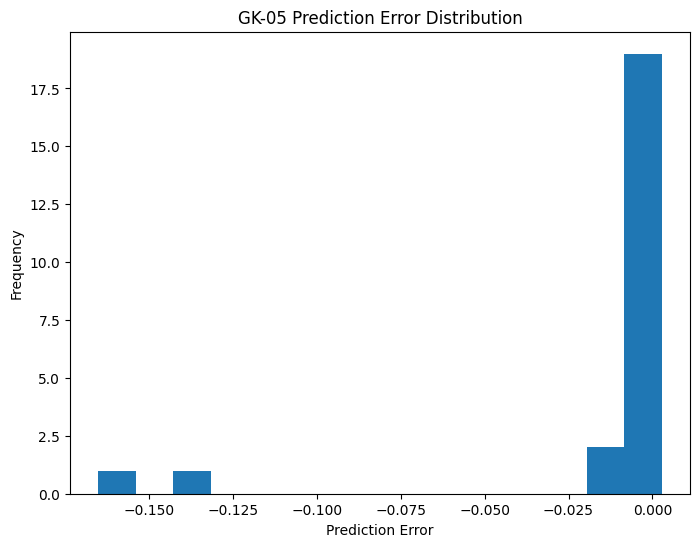

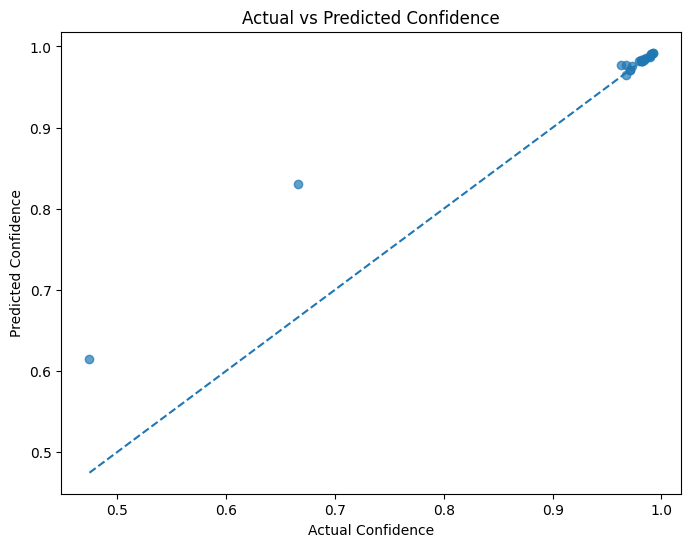

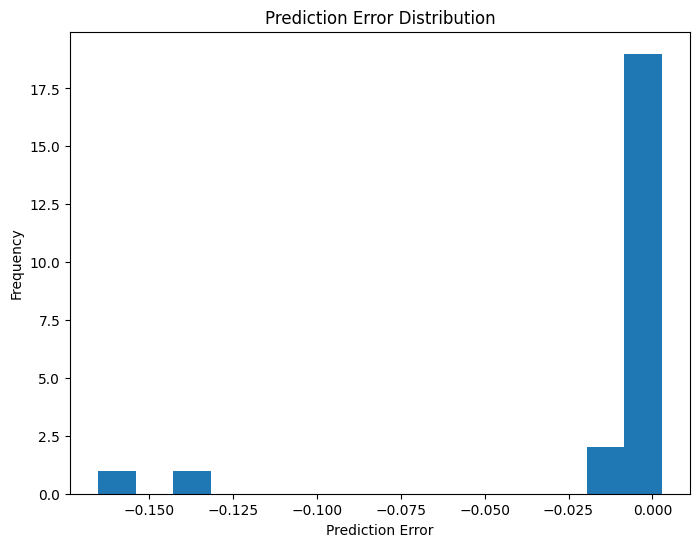

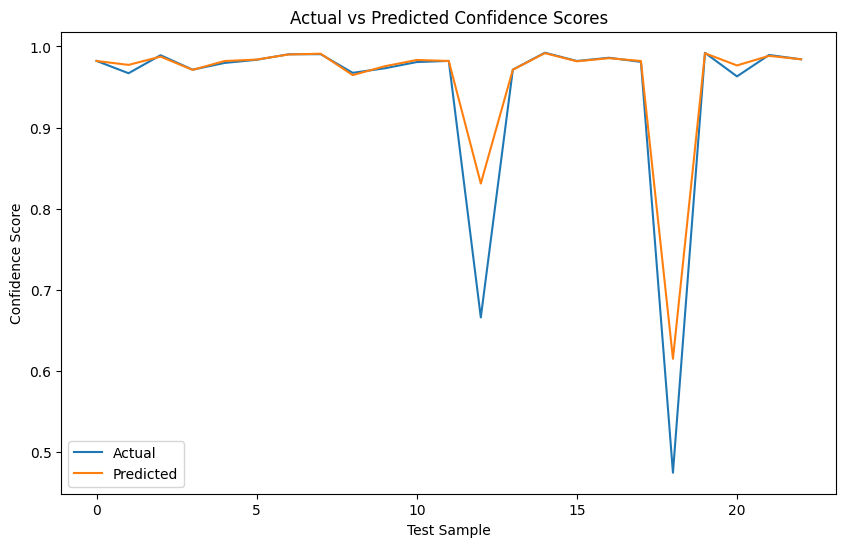

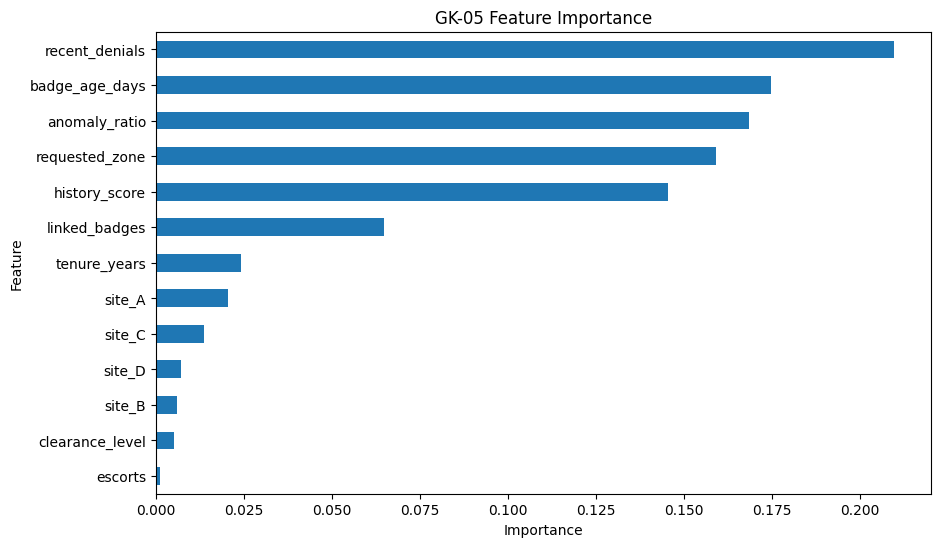

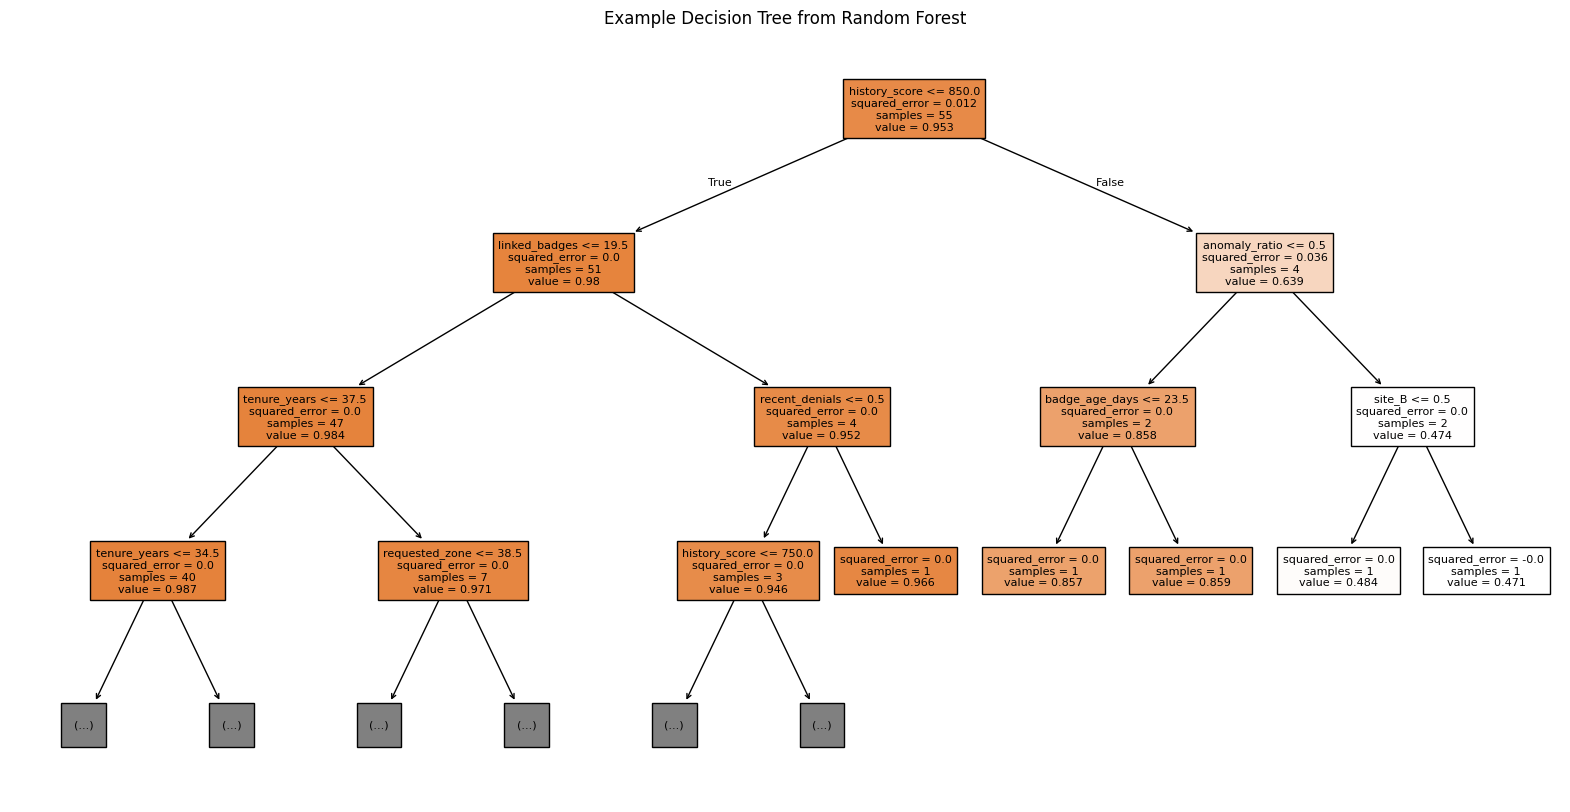

In [ ]:
# Prediction Error Distribution

errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=15)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("GK-05 Prediction Error Distribution")

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Confidence")
plt.ylabel("Predicted Confidence")
plt.title("Actual vs Predicted Confidence")

plt.show()

errors = y_test - y_pred

plt.figure(figsize=(8,6))
plt.hist(errors, bins=15)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")

plt.show()

plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("Confidence Score")
plt.title("Actual vs Predicted Confidence Scores")
plt.legend()

plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("GK-05 Feature Importance")

plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Example Decision Tree from Random Forest")
plt.show()



GK-05 Feature Importance:


,importance
recent_denials,0.209755
badge_age_days,0.174928
anomaly_ratio,0.168432
requested_zone,0.159064
history_score,0.145483
linked_badges,0.064811
tenure_years,0.024143
site_A,0.020491
site_C,0.013754
site_D,0.007013


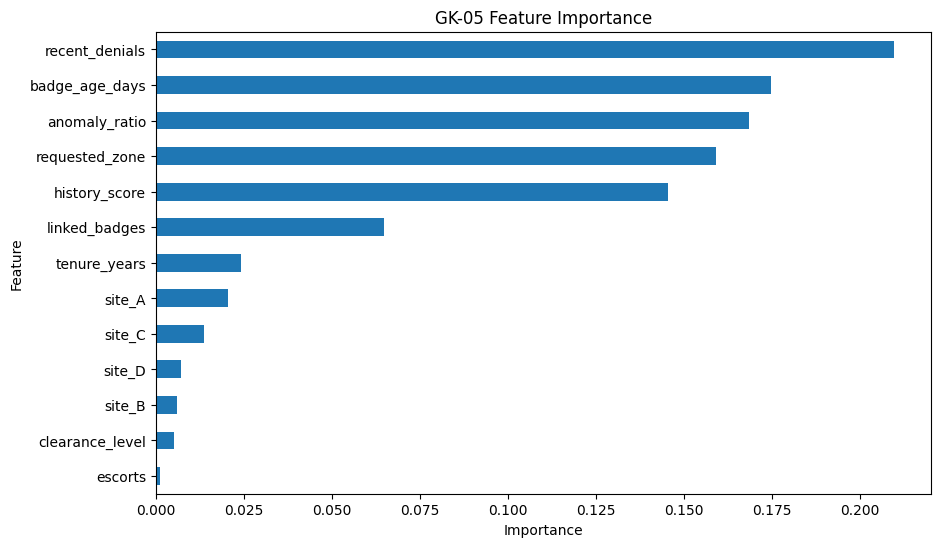

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("GK-05 Feature Importance:")
display(importance.to_frame("importance"))

importance.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("GK-05 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 5. Machine Learning Algorithm

We use Random Forest Regression to reconstruct the confidence score of the GK-05 black-box system.

Random Forest was selected because it can model nonlinear relationships and interactions between multiple input features and is suitable for small and medium-sized datasets.

In [ ]:
# Final Random Forest model using all available GK-05 data

from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_features="sqrt"
)

final_model.fit(X, y)

print("Final GK-05 model trained successfully!")
print("Training samples:", len(X))
print("Features:", X.shape[1])

Final GK-05 model trained successfully!
Training samples: 111
Features: 13


In [ ]:
def predict_gk05(
    clearance_level,
    badge_age_days,
    tenure_years,
    anomaly_ratio,
    history_score,
    linked_badges,
    recent_denials,
    requested_zone,
    escorts,
    site
):
    new_data = pd.DataFrame([{
        "clearance_level": clearance_level,
        "badge_age_days": badge_age_days,
        "tenure_years": tenure_years,
        "anomaly_ratio": anomaly_ratio,
        "history_score": history_score,
        "linked_badges": linked_badges,
        "recent_denials": recent_denials,
        "requested_zone": requested_zone,
        "escorts": escorts,
        "site": site
    }])

    new_data = pd.get_dummies(new_data, columns=["site"], dtype=int)

    # Make sure columns exactly match training data
    new_data = new_data.reindex(columns=X.columns, fill_value=0)

    prediction = final_model.predict(new_data)[0]

    return prediction

In [ ]:
prediction = predict_gk05(
    clearance_level=100,
    badge_age_days=24,
    tenure_years=34,
    anomaly_ratio=0,
    history_score=350,
    linked_badges=19,
    recent_denials=0,
    requested_zone=37,
    escorts=6,
    site="A"
)

print("Predicted GK-05 Confidence:", round(prediction, 4))
print("Predicted Decision: APPROVE" if prediction >= 0.5 else "Predicted Decision: DECLINE")

Predicted GK-05 Confidence: 0.9918
Predicted Decision: APPROVE


In [ ]:
actual_score = 0.9922
predicted_score = prediction

difference = abs(actual_score - predicted_score)

print("Reconstruction Comparison")
print("-------------------------")
print(f"Original GK-05 Score : {actual_score:.4f}")
print(f"Our Model Prediction : {predicted_score:.4f}")
print(f"Absolute Difference  : {difference:.4f}")
print("Decision             : APPROVE")

Reconstruction Comparison
-------------------------
Original GK-05 Score : 0.9922
Our Model Prediction : 0.9918
Absolute Difference  : 0.0004
Decision             : APPROVE


## 8. Conclusion

A small machine learning model was developed to reconstruct the observed behavior of the GK-05 building access control black box.

The dataset contains 111 observed GK-05 samples collected from the black-box system.

A Random Forest Regression model was selected because it can capture nonlinear relationships and interactions between features.

The initial test evaluation achieved:

- Mean Absolute Error (MAE): 0.0151
- Root Mean Squared Error (RMSE): 0.0454
- R² Score: 0.8557

The final model was trained using all available observations.

For a known GK-05 baseline input, the original black box produced a confidence score of 0.9922, while our reconstructed model predicted 0.9918.

This gives an absolute difference of only 0.0004 for this test case.

The model therefore provides a useful ML-based approximation of the observed GK-05 black-box behavior.